# ============================================================
# Author: Mayur Deshmukh
# Name: 04_model_predict.ipynb
# Project: ML-Binary-Classifier-For-Stock-Price-rediction
# Purpose: Training ML Models for Binary Classification
# Python Version: 3.11
# ============================================================

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
from sklearn.model_selection import GridSearchCV

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

output_dir = os.path.join('..', '..', 'output')

In [8]:
# Load feature-engineered and pre-split datasets from the output folder
X_train = pd.read_csv(os.path.join(output_dir, 'X_train.csv'))
X_test  = pd.read_csv(os.path.join(output_dir, 'X_test.csv'))
y_train = pd.read_csv(os.path.join(output_dir, 'y_train.csv')).squeeze()
y_test  = pd.read_csv(os.path.join(output_dir, 'y_test.csv')).squeeze()

print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}  |  y_test : {y_test.shape}")
print(f"\ny_train distribution:\n{y_train.value_counts()}")
print(f"\ny_test  distribution:\n{y_test.value_counts()}")

X_train : (9330, 17)  |  X_test : (2770, 17)
y_train : (9330,)  |  y_test : (2770,)

y_train distribution:
target
1    4818
0    4512
Name: count, dtype: int64

y_test  distribution:
target
1    1500
0    1270
Name: count, dtype: int64


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
from sklearn.model_selection import GridSearchCV

print("=" * 60)
print("=== STEP 1: LOGISTIC REGRESSION — BASELINE ===")
print("=" * 60)

# Train a baseline Logistic Regression with default parameters
try:
    lr_baseline = LogisticRegression(random_state=42, max_iter=200, n_jobs=-1)
    lr_baseline.fit(X_train, y_train)

    y_pred_baseline = lr_baseline.predict(X_test)
    y_prob_baseline = lr_baseline.predict_proba(X_test)[:, 1]

    print(f"Baseline Accuracy  : {accuracy_score(y_test, y_pred_baseline):.4f}")
    print(f"Baseline Precision : {precision_score(y_test, y_pred_baseline):.4f}")
    print(f"Baseline Recall    : {recall_score(y_test, y_pred_baseline):.4f}")
    print(f"Baseline F1        : {f1_score(y_test, y_pred_baseline):.4f}")
    print(f"Baseline ROC-AUC   : {roc_auc_score(y_test, y_prob_baseline):.4f}")

except Exception as e:
    print(f"[ERROR] Baseline Logistic Regression failed: {e}")

=== STEP 1: LOGISTIC REGRESSION — BASELINE ===
Baseline Accuracy  : 0.6690
Baseline Precision : 0.6628
Baseline Recall    : 0.7913
Baseline F1        : 0.7214
Baseline ROC-AUC   : 0.7424


In [4]:
print("=" * 60)
print("=== STEP 1: LOGISTIC REGRESSION — HYPERPARAMETER TUNING ===")
print("=" * 60)

# GridSearchCV with multiple scoring metrics; refit on roc_auc
param_grid = {
    'C'        : [0.01, 0.1, 1, 10, 100],
    'penalty'  : ['l1', 'l2'],
    'solver'   : ['liblinear', 'saga'],
    'max_iter' : [200, 500]
}

scoring = {
    'roc_auc'  : 'roc_auc',
    'f1'       : 'f1',
    'accuracy' : 'accuracy',
    'precision': 'precision',
    'recall'   : 'recall'
}

try:
    lr_grid = GridSearchCV(
        estimator  = LogisticRegression(random_state=42, n_jobs=-1),
        param_grid = param_grid,
        scoring    = scoring,
        refit      = 'roc_auc',
        cv         = 5,
        n_jobs     = -1,
        verbose    = 1
    )
    lr_grid.fit(X_train, y_train)

    print(f"\nBest hyperparameters found:")
    for param, val in lr_grid.best_params_.items():
        print(f"  {param}: {val}")
    print(f"\nBest CV ROC-AUC: {lr_grid.best_score_:.4f}")

except Exception as e:
    print(f"[ERROR] GridSearchCV for Logistic Regression failed: {e}")

=== STEP 1: LOGISTIC REGRESSION — HYPERPARAMETER TUNING ===
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best hyperparameters found:
  C: 100
  max_iter: 500
  penalty: l1
  solver: liblinear

Best CV ROC-AUC: 0.9363


In [5]:
print("=" * 60)
print("=== STEP 1: LOGISTIC REGRESSION — FINAL PREDICTIONS ===")
print("=" * 60)

# Use the best estimator from GridSearchCV for final predictions on test set
try:
    lr_best = lr_grid.best_estimator_

    y_pred_lr = lr_best.predict(X_test)
    y_prob_lr = lr_best.predict_proba(X_test)[:, 1]

    print(f"Tuned Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")
    print(f"Tuned Precision : {precision_score(y_test, y_pred_lr):.4f}")
    print(f"Tuned Recall    : {recall_score(y_test, y_pred_lr):.4f}")
    print(f"Tuned F1        : {f1_score(y_test, y_pred_lr):.4f}")
    print(f"Tuned ROC-AUC   : {roc_auc_score(y_test, y_prob_lr):.4f}")

    print(f"\nClassification Report:\n")
    print(classification_report(y_test, y_pred_lr, target_names=['Down (0)', 'Up (1)']))

except Exception as e:
    print(f"[ERROR] Final predictions for Logistic Regression failed: {e}")

=== STEP 1: LOGISTIC REGRESSION — FINAL PREDICTIONS ===
Tuned Accuracy  : 0.8610
Tuned Precision : 0.8535
Tuned Recall    : 0.8973
Tuned F1        : 0.8749
Tuned ROC-AUC   : 0.9354

Classification Report:

              precision    recall  f1-score   support

    Down (0)       0.87      0.82      0.84      1270
      Up (1)       0.85      0.90      0.87      1500

    accuracy                           0.86      2770
   macro avg       0.86      0.86      0.86      2770
weighted avg       0.86      0.86      0.86      2770



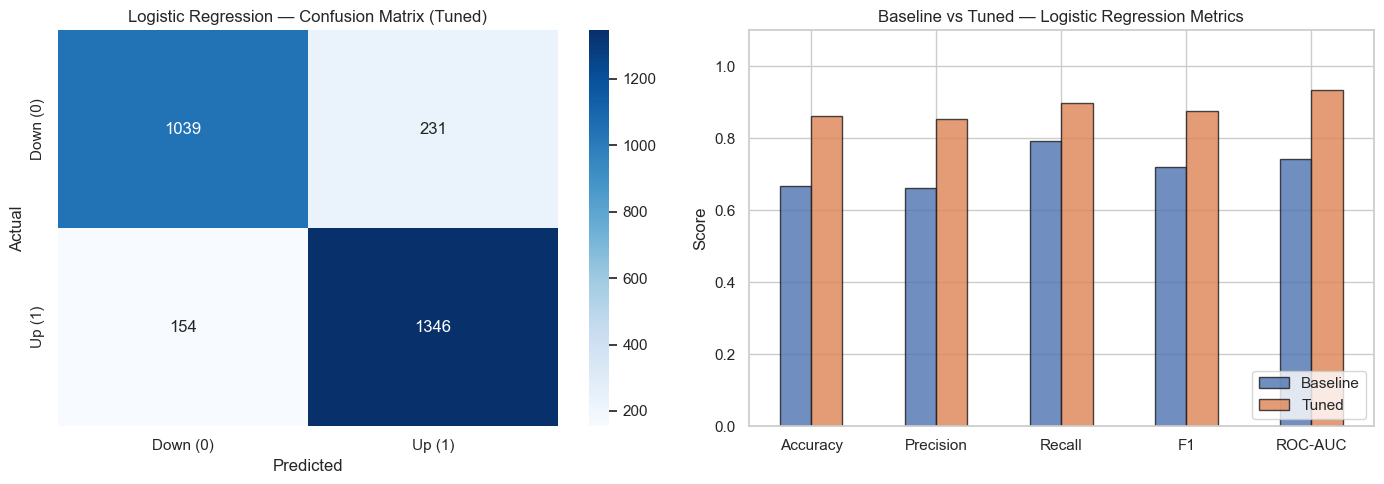


Baseline vs Tuned Metrics:


,Baseline,Tuned
Accuracy,0.6690,0.8610
Precision,0.6628,0.8535
Recall,0.7913,0.8973
F1,0.7214,0.8749
ROC-AUC,0.7424,0.9354


In [6]:
# Plot confusion matrix and compare baseline vs tuned metrics side by side
try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion matrix — tuned model
    cm = confusion_matrix(y_test, y_pred_lr)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Down (0)', 'Up (1)'],
                yticklabels=['Down (0)', 'Up (1)'])
    axes[0].set_title('Logistic Regression — Confusion Matrix (Tuned)')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    # Bar chart: baseline vs tuned metrics
    metrics_compare = pd.DataFrame({
        'Baseline': {
            'Accuracy' : accuracy_score(y_test, y_pred_baseline),
            'Precision': precision_score(y_test, y_pred_baseline),
            'Recall'   : recall_score(y_test, y_pred_baseline),
            'F1'       : f1_score(y_test, y_pred_baseline),
            'ROC-AUC'  : roc_auc_score(y_test, y_prob_baseline)
        },
        'Tuned': {
            'Accuracy' : accuracy_score(y_test, y_pred_lr),
            'Precision': precision_score(y_test, y_pred_lr),
            'Recall'   : recall_score(y_test, y_pred_lr),
            'F1'       : f1_score(y_test, y_pred_lr),
            'ROC-AUC'  : roc_auc_score(y_test, y_prob_lr)
        }
    })

    metrics_compare.plot(kind='bar', ax=axes[1], edgecolor='k', alpha=0.8)
    axes[1].set_title('Baseline vs Tuned — Logistic Regression Metrics')
    axes[1].set_ylabel('Score')
    axes[1].set_ylim(0, 1.1)
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].legend(loc='lower right')

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'lr_evaluation.png'), bbox_inches='tight')
    plt.show()

    print("\nBaseline vs Tuned Metrics:")
    display(metrics_compare.round(4))

except Exception as e:
    print(f"[ERROR] Plotting failed: {e}")

In [9]:
from sklearn.svm import SVC

print("=" * 60)
print("=== STEP 2: SUPPORT VECTOR MACHINE — BASELINE ===")
print("=" * 60)

# Train a baseline SVC with default parameters; probability=True enables ROC-AUC scoring
try:
    svc_baseline = SVC(random_state=42, probability=True)
    svc_baseline.fit(X_train, y_train)

    y_pred_svc_baseline = svc_baseline.predict(X_test)
    y_prob_svc_baseline = svc_baseline.predict_proba(X_test)[:, 1]

    print(f"Baseline Accuracy  : {accuracy_score(y_test, y_pred_svc_baseline):.4f}")
    print(f"Baseline Precision : {precision_score(y_test, y_pred_svc_baseline):.4f}")
    print(f"Baseline Recall    : {recall_score(y_test, y_pred_svc_baseline):.4f}")
    print(f"Baseline F1        : {f1_score(y_test, y_pred_svc_baseline):.4f}")
    print(f"Baseline ROC-AUC   : {roc_auc_score(y_test, y_prob_svc_baseline):.4f}")

except Exception as e:
    print(f"[ERROR] Baseline SVM failed: {e}")

=== STEP 2: SUPPORT VECTOR MACHINE — BASELINE ===
Baseline Accuracy  : 0.7079
Baseline Precision : 0.6987
Baseline Recall    : 0.8100
Baseline F1        : 0.7502
Baseline ROC-AUC   : 0.7766


In [ ]:
print("=" * 60)
print("=== STEP 2: SUPPORT VECTOR MACHINE — HYPERPARAMETER TUNING ===")
print("=" * 60)

# GridSearchCV over C, kernel, and gamma; probability=True required for roc_auc scoring
svc_param_grid = {
    'C'      : [0.1, 1, 10, 100],
    'kernel' : ['linear', 'rbf', 'poly'],
    'gamma'  : ['scale', 'auto']
}

svc_scoring = {
    'roc_auc'  : 'roc_auc',
    'f1'       : 'f1',
    'accuracy' : 'accuracy',
    'precision': 'precision',
    'recall'   : 'recall'
}

try:
    svc_grid = GridSearchCV(
        estimator  = SVC(random_state=42, probability=True),
        param_grid = svc_param_grid,
        scoring    = svc_scoring,
        refit      = 'roc_auc',
        cv         = 5,
        n_jobs     = -1,
        verbose    = 1
    )
    svc_grid.fit(X_train, y_train)

    print(f"\nBest hyperparameters found:")
    for param, val in svc_grid.best_params_.items():
        print(f"  {param}: {val}")
    print(f"\nBest CV ROC-AUC: {svc_grid.best_score_:.4f}")

except Exception as e:
    print(f"[ERROR] GridSearchCV for SVM failed: {e}")

=== STEP 2: SUPPORT VECTOR MACHINE — HYPERPARAMETER TUNING ===
Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [ ]:
print("=" * 60)
print("=== STEP 2: SUPPORT VECTOR MACHINE — FINAL PREDICTIONS ===")
print("=" * 60)

# Use the best estimator from GridSearchCV to generate final test set predictions
try:
    svc_best = svc_grid.best_estimator_

    y_pred_svc = svc_best.predict(X_test)
    y_prob_svc = svc_best.predict_proba(X_test)[:, 1]

    print(f"Tuned Accuracy  : {accuracy_score(y_test, y_pred_svc):.4f}")
    print(f"Tuned Precision : {precision_score(y_test, y_pred_svc):.4f}")
    print(f"Tuned Recall    : {recall_score(y_test, y_pred_svc):.4f}")
    print(f"Tuned F1        : {f1_score(y_test, y_pred_svc):.4f}")
    print(f"Tuned ROC-AUC   : {roc_auc_score(y_test, y_prob_svc):.4f}")

    print(f"\nClassification Report:\n")
    print(classification_report(y_test, y_pred_svc, target_names=['Down (0)', 'Up (1)']))

except Exception as e:
    print(f"[ERROR] Final predictions for SVM failed: {e}")

=== STEP 2: SUPPORT VECTOR MACHINE — FINAL PREDICTIONS ===
[ERROR] Final predictions for SVM failed: name 'svc_grid' is not defined


[ERROR] SVM plotting failed: name 'confusion_matrix' is not defined


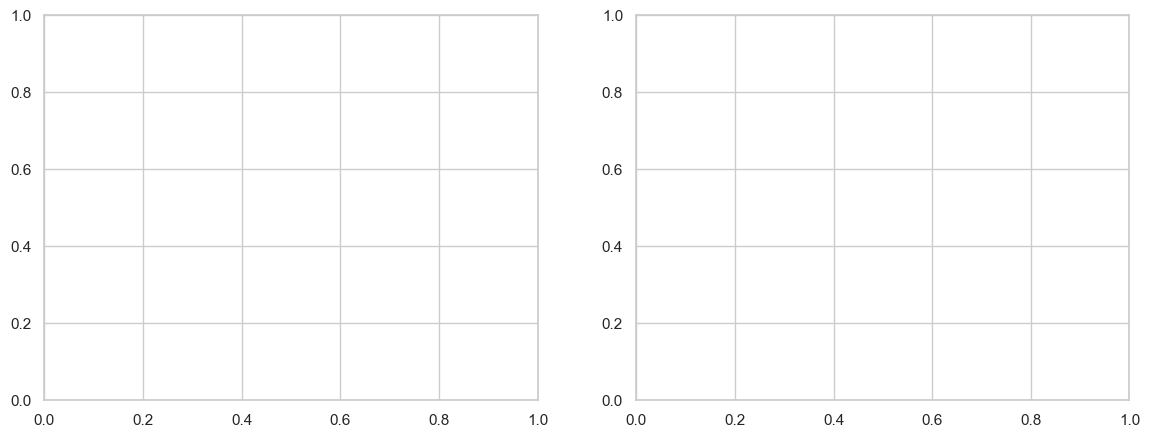

In [ ]:
# Plot SVM confusion matrix and compare baseline vs tuned metrics side by side
try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion matrix — tuned SVM
    cm_svc = confusion_matrix(y_test, y_pred_svc)
    sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
                xticklabels=['Down (0)', 'Up (1)'],
                yticklabels=['Down (0)', 'Up (1)'])
    axes[0].set_title('SVM — Confusion Matrix (Tuned)')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    # Bar chart: SVM baseline vs tuned metrics
    svc_metrics_compare = pd.DataFrame({
        'Baseline': {
            'Accuracy' : accuracy_score(y_test, y_pred_svc_baseline),
            'Precision': precision_score(y_test, y_pred_svc_baseline),
            'Recall'   : recall_score(y_test, y_pred_svc_baseline),
            'F1'       : f1_score(y_test, y_pred_svc_baseline),
            'ROC-AUC'  : roc_auc_score(y_test, y_prob_svc_baseline)
        },
        'Tuned': {
            'Accuracy' : accuracy_score(y_test, y_pred_svc),
            'Precision': precision_score(y_test, y_pred_svc),
            'Recall'   : recall_score(y_test, y_pred_svc),
            'F1'       : f1_score(y_test, y_pred_svc),
            'ROC-AUC'  : roc_auc_score(y_test, y_prob_svc)
        }
    })

    svc_metrics_compare.plot(kind='bar', ax=axes[1], edgecolor='k', alpha=0.8)
    axes[1].set_title('Baseline vs Tuned — SVM Metrics')
    axes[1].set_ylabel('Score')
    axes[1].set_ylim(0, 1.1)
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].legend(loc='lower right')

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'svm_evaluation.png'), bbox_inches='tight')
    plt.show()

    print("\nSVM Baseline vs Tuned Metrics:")
    display(svc_metrics_compare.round(4))

except Exception as e:
    print(f"[ERROR] SVM plotting failed: {e}")